In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
bb = pd.read_csv('/home/claude/bigbench.csv')
mmlu = pd.read_csv('/home/claude/mmlu.csv')

# --- Classify methods ---
def classify_method(row):
    path = row['model_path'] if 'model_path' in row.index else row['model_name']
    if 'uiortholora' in path:
        # Check if svec > 0
        if 'svec64' in path or 'svec32' in path or ('_v32_' in path) or ('_v64_' in path):
            return 'OrthoLoRA+Vec'
        else:
            return 'OrthoLoRA'
    elif 'lora' in path:
        return 'LoRA'
    return 'Other'

def get_model_family(row):
    path = row['model_path'] if 'model_path' in row.index else row['model_name']
    if 'gemma-12b' in path:
        return 'Gemma-12B'
    elif 'Llama-3.2-3B' in path:
        return 'Llama-3.2-3B'
    return 'Other'

bb['method'] = bb.apply(classify_method, axis=1)
bb['model_family'] = bb.apply(get_model_family, axis=1)
mmlu['method'] = mmlu.apply(classify_method, axis=1)
mmlu['model_family'] = mmlu.apply(get_model_family, axis=1)

# Deduplicate bb (some lora rows are repeated with same accuracy)
bb_dedup = bb.drop_duplicates(subset=['model_path', 'mean_accuracy'])

colors = {'LoRA': '#2196F3', 'OrthoLoRA': '#FF9800', 'OrthoLoRA+Vec': '#4CAF50'}

# ============================================================
# FIGURE 1: BigBench mean_accuracy distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BigBench Mean Accuracy Distribution by Method', fontsize=14, fontweight='bold')

for ax, family in zip(axes[:2], ['Llama-3.2-3B', 'Gemma-12B']):
    subset = bb_dedup[bb_dedup['model_family'] == family]
    methods_present = [m for m in ['LoRA', 'OrthoLoRA', 'OrthoLoRA+Vec'] if m in subset['method'].values]
    data = [subset[subset['method'] == m]['mean_accuracy'].values for m in methods_present]
    cols = [colors[m] for m in methods_present]
    
    bins = np.linspace(
        subset['mean_accuracy'].min() - 0.02,
        subset['mean_accuracy'].max() + 0.02,
        15
    )
    for d, c, m in zip(data, cols, methods_present):
        ax.hist(d, bins=bins, alpha=0.55, color=c, label=f'{m} (n={len(d)}, μ={np.mean(d):.3f})', edgecolor='white')
    ax.set_title(family)
    ax.set_xlabel('Mean Accuracy')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Combined
ax = axes[2]
for m in ['LoRA', 'OrthoLoRA', 'OrthoLoRA+Vec']:
    vals = bb_dedup[bb_dedup['method'] == m]['mean_accuracy'].values
    if len(vals) > 0:
        ax.hist(vals, bins=15, alpha=0.55, color=colors[m],
                label=f'{m} (n={len(vals)}, μ={np.mean(vals):.3f})', edgecolor='white')
ax.set_title('All Models Combined')
ax.set_xlabel('Mean Accuracy')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/home/claude/bigbench_hist.png', dpi=150, bbox_inches='tight')
plt.close()

# ============================================================
# FIGURE 2: MMLU accuracy distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MMLU Accuracy Distribution by Method', fontsize=14, fontweight='bold')

for ax, family in zip(axes[:2], ['Llama-3.2-3B', 'Gemma-12B']):
    subset = mmlu[mmlu['model_family'] == family]
    methods_present = [m for m in ['LoRA', 'OrthoLoRA', 'OrthoLoRA+Vec'] if m in subset['method'].values]
    data = [subset[subset['method'] == m]['mmlu_acc'].values for m in methods_present]
    cols = [colors[m] for m in methods_present]
    
    bins = np.linspace(
        subset['mmlu_acc'].min() - 0.02,
        subset['mmlu_acc'].max() + 0.02,
        15
    )
    for d, c, m in zip(data, cols, methods_present):
        ax.hist(d, bins=bins, alpha=0.55, color=c, label=f'{m} (n={len(d)}, μ={np.mean(d):.3f})', edgecolor='white')
    ax.set_title(family)
    ax.set_xlabel('MMLU Accuracy')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

ax = axes[2]
for m in ['LoRA', 'OrthoLoRA', 'OrthoLoRA+Vec']:
    vals = mmlu[mmlu['method'] == m]['mmlu_acc'].values
    if len(vals) > 0:
        ax.hist(vals, bins=15, alpha=0.55, color=colors[m],
                label=f'{m} (n={len(vals)}, μ={np.mean(vals):.3f})', edgecolor='white')
ax.set_title('All Models Combined')
ax.set_xlabel('MMLU Accuracy')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/home/claude/mmlu_hist.png', dpi=150, bbox_inches='tight')
plt.close()

# ============================================================
# FIGURE 3: Per-task BigBench accuracy (Llama only, most data)
# ============================================================
task_cols = [c for c in bb.columns if c.startswith('acc_')]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('BigBench Per-Task Accuracy (Llama-3.2-3B): LoRA vs OrthoLoRA', fontsize=14, fontweight='bold')

subset = bb_dedup[bb_dedup['model_family'] == 'Llama-3.2-3B']
for ax, task in zip(axes.flat, task_cols):
    task_name = task.replace('acc_', '').replace('_', ' ').title()
    for m in ['LoRA', 'OrthoLoRA', 'OrthoLoRA+Vec']:
        vals = subset[subset['method'] == m][task].values
        if len(vals) > 0:
            ax.hist(vals, bins=10, alpha=0.55, color=colors[m], label=m, edgecolor='white')
    ax.set_title(task_name, fontsize=10)
    ax.tick_params(labelsize=8)

axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/home/claude/pertask_hist.png', dpi=150, bbox_inches='tight')
plt.close()

# Print summary stats
print("=== BigBench Summary ===")
print(bb_dedup.groupby(['model_family', 'method'])['mean_accuracy'].agg(['count', 'mean', 'std', 'min', 'max']).round(4))
print("\n=== MMLU Summary ===")
print(mmlu.groupby(['model_family', 'method'])['mmlu_acc'].agg(['count', 'mean', 'std', 'min', 'max']).round(4))

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/bigbench.csv'

In [2]:
# %% ── Cell 1: Imports & Config ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ──
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "grid.alpha": 0.6,
    "font.family": "monospace",
    "font.size": 11,
})

# ── Edit these ──
MODELS = ["gemma-12b", "llama-3b"]
DATASETS = ["hotpotqa", "triviaqa"]
THRESHOLDS = [0.6, 0.8]
BASE_DIR = Path("./adapters_results")

ADAPTER_COLORS = {
    "lora": "#58a6ff",
    "uiortholora": "#f78166",
    "vera": "#7ee787",
}
ADAPTER_MARKERS = {
    "lora": "o",
    "uiortholora": "s",
    "vera": "^",
}


In [3]:
def load_intrinsic(model, dataset, threshold):
    """Load per-adapter accuracy/shift CSV. Drops incomplete rows."""
    path = BASE_DIR / dataset / f"threshold_{threshold}" / f"{model}.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = df.dropna(subset=["accuracy"])
    df = df[df["accuracy"] > 0]
    df = df[df["tr_actual"] > 0]
    return df


def load_mmlu(dataset):
    path = BASE_DIR / dataset / "mmlu_summary.csv"
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def load_bigbench(dataset):
    path = BASE_DIR / dataset / "bigbench_summary.csv"
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def match_extrinsic(raw_adapter_name, ext_df, name_col="model_name"):
    """Fuzzy-match adapter name to a row in MMLU/BigBench summary."""
    if ext_df.empty or raw_adapter_name is None:
        return None
    col = "model_path" if "model_path" in ext_df.columns else name_col
    for _, row in ext_df.iterrows():
        val = str(row.get(col, ""))
        if raw_adapter_name in val or val.endswith(raw_adapter_name):
            return row
    return None


def plot_scatter(model, dataset, threshold, ax):
    """
    Core scatter: accuracy (Y) vs negative_shift_count (X).
    Colored by adapter_type, annotated with lr/rank.
    """
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=16, color="#8b949e")
        ax.set_title(f"{model} / {dataset}  (t={threshold})", fontsize=14, fontweight="bold")
        return df

    for atype in sorted(df["adapter_type"].dropna().unique()):
        sub = df[df["adapter_type"] == atype]
        color = ADAPTER_COLORS.get(atype, "#999")
        marker = ADAPTER_MARKERS.get(atype, "o")

        ax.scatter(
            sub["negative_shift_count"], sub["accuracy"],
            c=color, marker=marker, s=80, alpha=0.85,
            edgecolors="white", linewidths=0.5, label=atype, zorder=5,
        )

        # Annotate if not too crowded
        if len(sub) <= 40:
            for _, row in sub.iterrows():
                parts = []
                if pd.notna(row.get("lr")):
                    parts.append(f"lr={row['lr']}")
                if pd.notna(row.get("rank")) and str(row.get("rank", "")) not in ("", "nan"):
                    parts.append(f"r={int(float(row['rank']))}")
                label = "\n".join(parts)
                if label:
                    ax.annotate(label, (row["negative_shift_count"], row["accuracy"]),
                                textcoords="offset points", xytext=(6, 6),
                                fontsize=7, color="#8b949e", alpha=0.85)

    ax.set_xlabel("Negative Shift Count  → (forgetting)", fontsize=12)
    ax.set_ylabel("Accuracy  ↑ (learning)", fontsize=12)
    ax.set_title(f"{model} / {dataset}  (threshold={threshold})", fontsize=14, fontweight="bold")
    ax.legend(loc="best", framealpha=0.3, fontsize=10)
    ax.grid(True, alpha=0.3)
    return df


def print_summary(model, dataset, threshold):
    """Print a compact summary table with optional MMLU/BigBench columns."""
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        print(f"  No data for {model}/{dataset} t={threshold}")
        return

    mmlu = load_mmlu(dataset)
    bb = load_bigbench(dataset)

    rows = []
    for _, r in df.iterrows():
        name = r.get("raw_adapter_name", "")
        row = {
            "adapter": name,
            "type": r.get("adapter_type", ""),
            "lr": r.get("lr", ""),
            "rank": r.get("rank", ""),
            "accuracy": round(r["accuracy"], 4),
            "neg_shift": int(r["negative_shift_count"]),
        }
        mmlu_row = match_extrinsic(name, mmlu)
        row["mmlu"] = round(mmlu_row["mmlu_acc"], 4) if mmlu_row is not None else None

        bb_row = match_extrinsic(name, bb, name_col="model_path")
        row["bigbench"] = round(bb_row["mean_accuracy"], 4) if bb_row is not None else None

        rows.append(row)

    summary = pd.DataFrame(rows).sort_values(["type", "neg_shift"])
    cols = ["adapter", "type", "lr", "rank", "accuracy", "neg_shift", "mmlu", "bigbench"]
    print(summary[cols].to_string(index=False))
    return summary

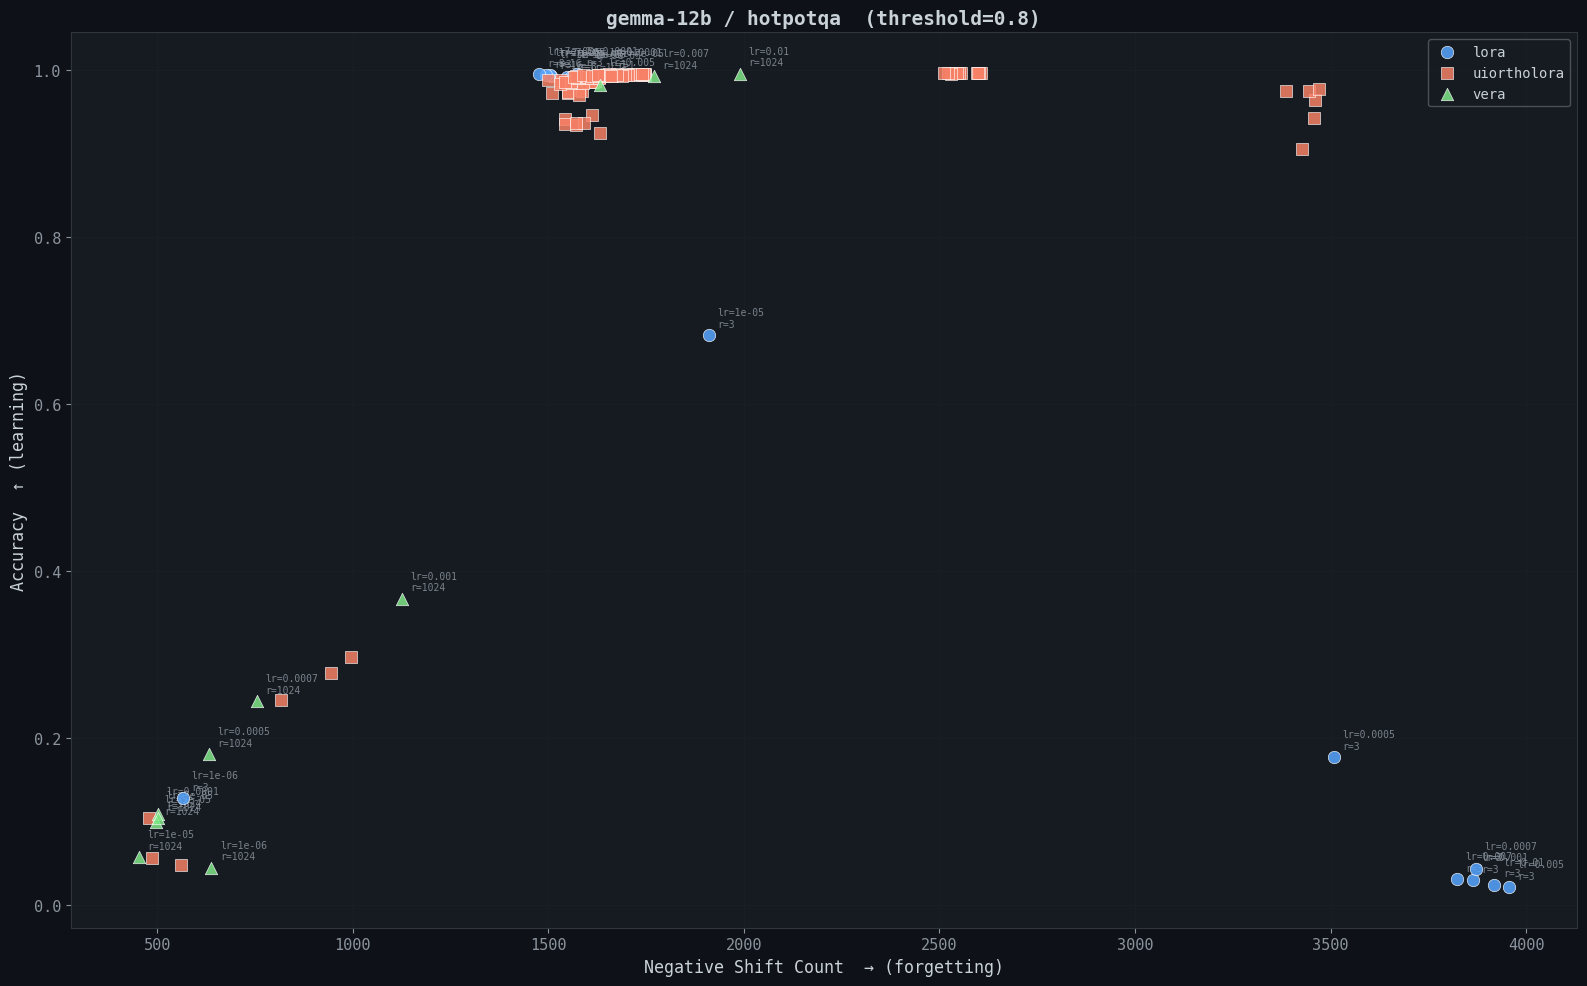


──────────────────────────────────────────────────────────────────────
  gemma-12b / hotpotqa  |  threshold=0.8  |  126 adapters
──────────────────────────────────────────────────────────────────────
  lora             n= 18  acc=[0.021–0.996]  neg=[566–3955]
  uiortholora      n= 97  acc=[0.048–0.997]  neg=[478–3471]
  vera             n= 11  acc=[0.045–0.996]  neg=[454–1989]



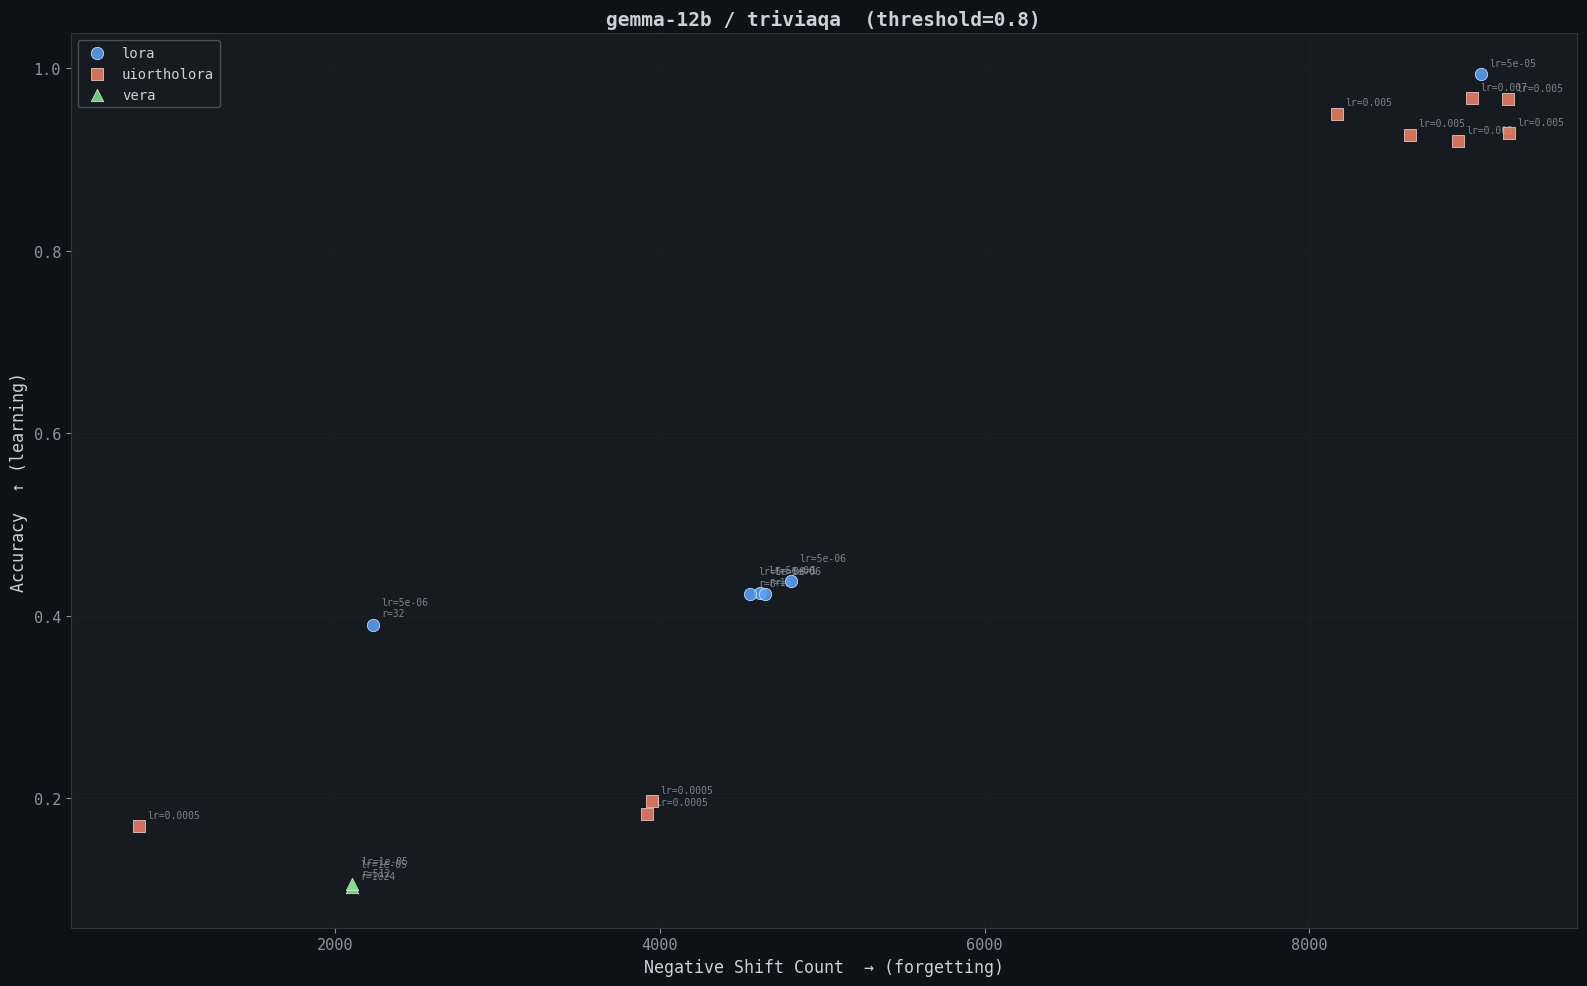


──────────────────────────────────────────────────────────────────────
  gemma-12b / triviaqa  |  threshold=0.8  |  17 adapters
──────────────────────────────────────────────────────────────────────
  lora             n=  6  acc=[0.390–0.993]  neg=[2233–9058]
  uiortholora      n=  9  acc=[0.169–0.967]  neg=[794–9227]
  vera             n=  2  acc=[0.103–0.106]  neg=[2107–2108]



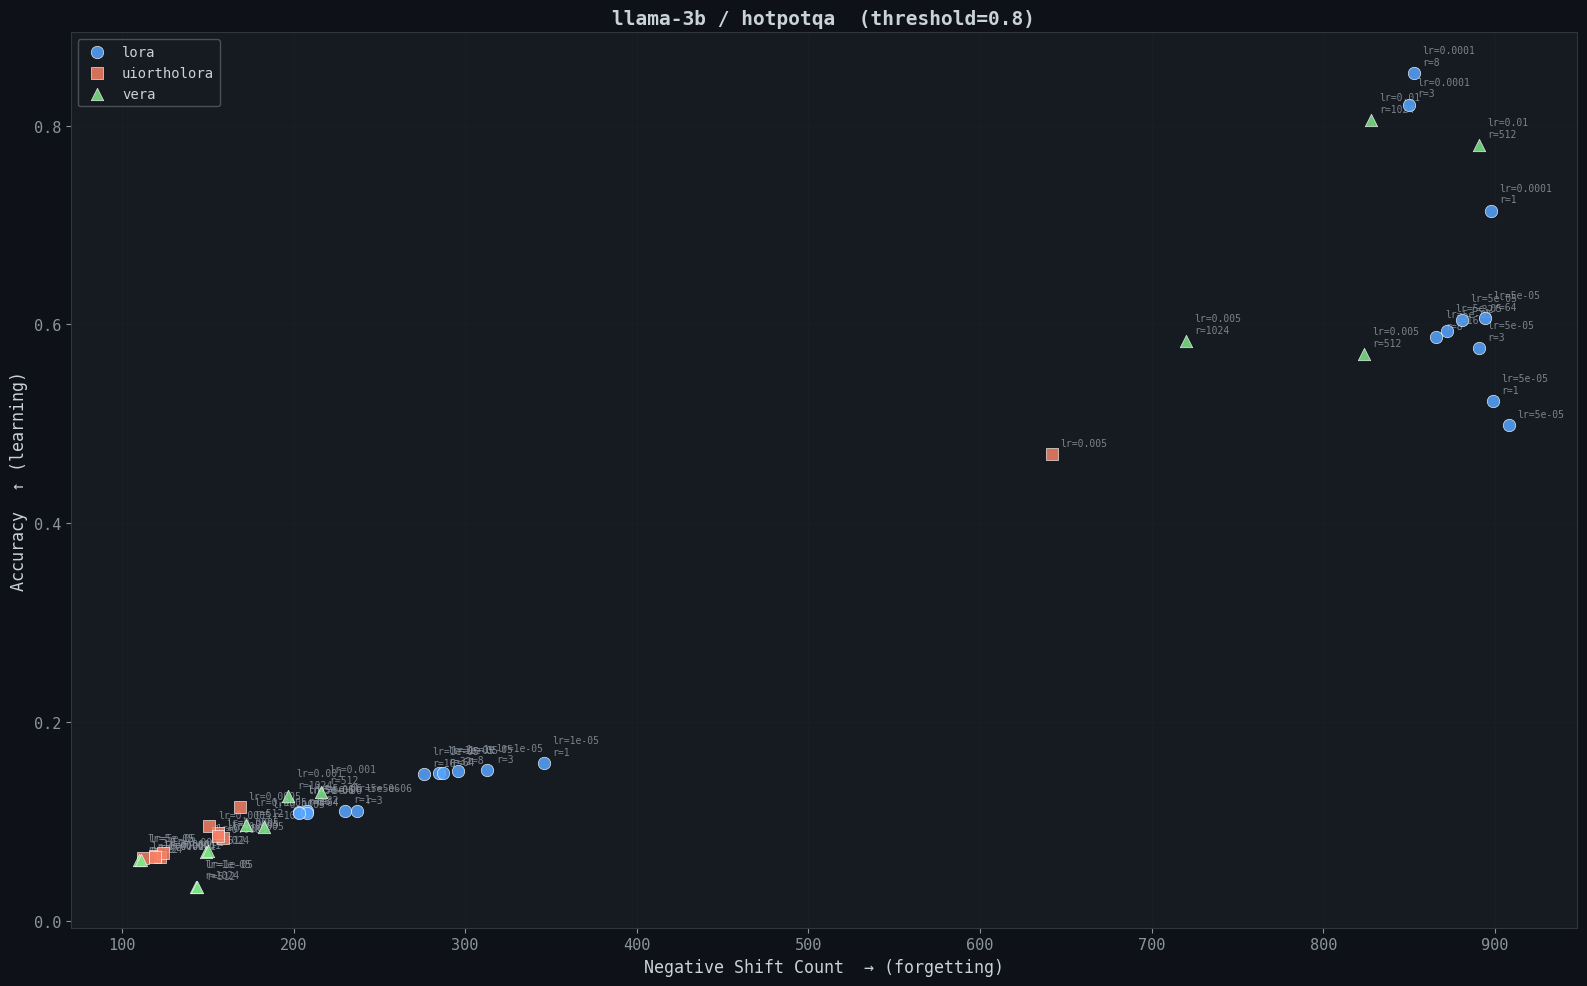


──────────────────────────────────────────────────────────────────────
  llama-3b / hotpotqa  |  threshold=0.8  |  47 adapters
──────────────────────────────────────────────────────────────────────
  lora             n= 22  acc=[0.108–0.853]  neg=[203–908]
  uiortholora      n= 11  acc=[0.063–0.470]  neg=[112–642]
  vera             n= 14  acc=[0.034–0.805]  neg=[110–891]



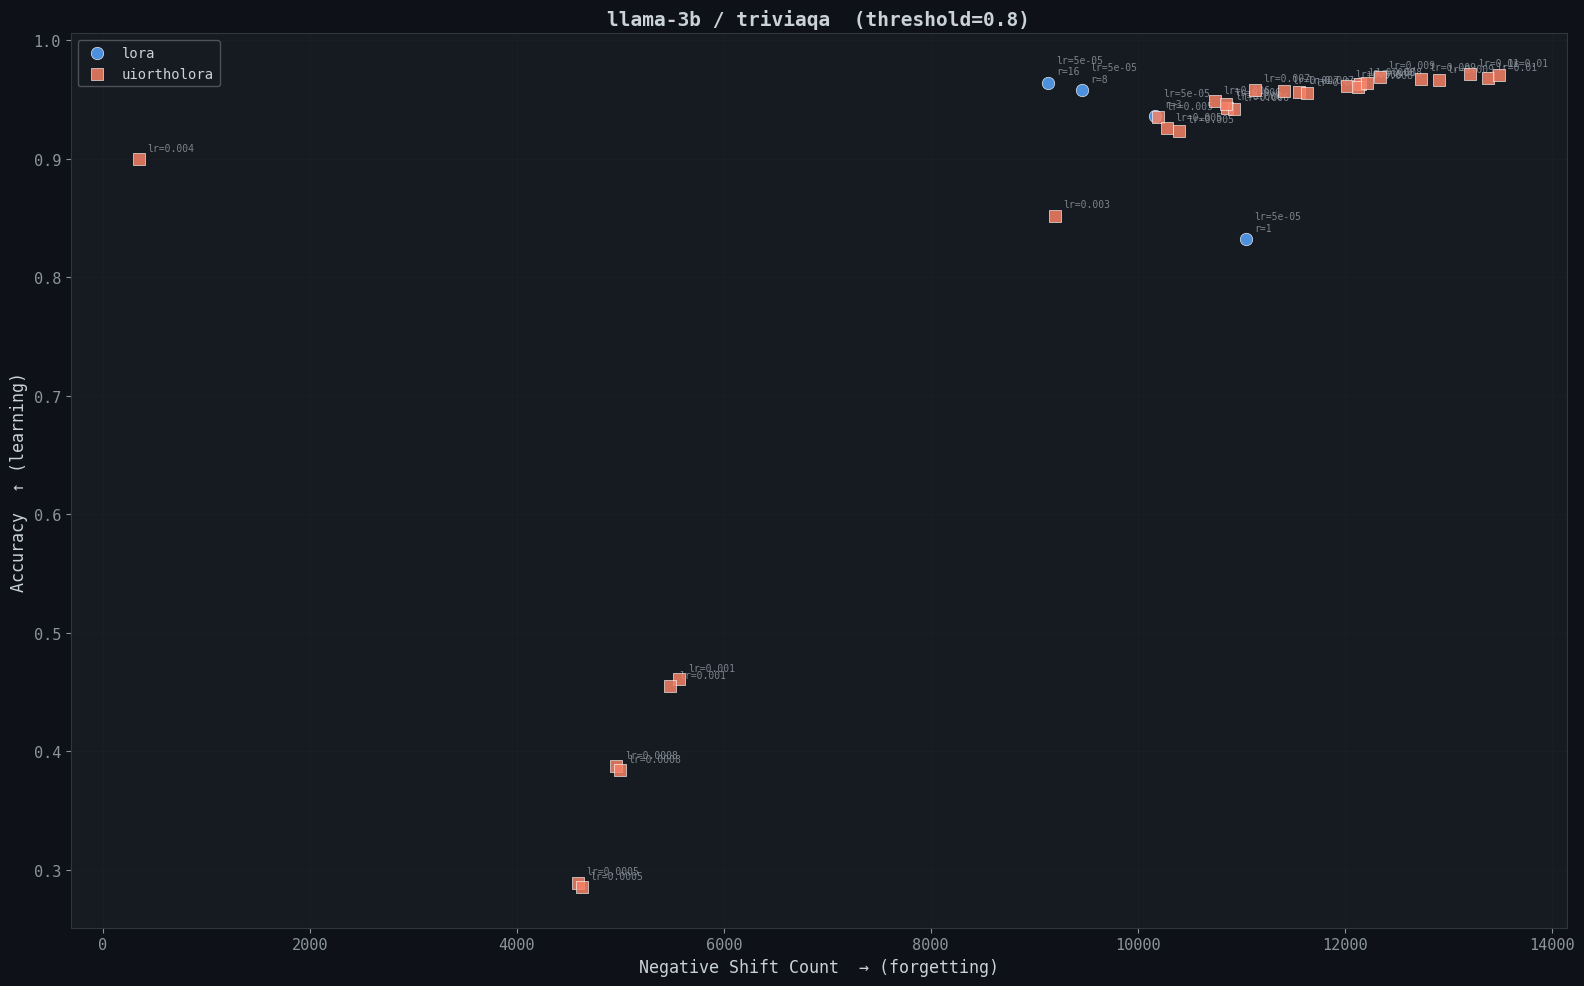


──────────────────────────────────────────────────────────────────────
  llama-3b / triviaqa  |  threshold=0.8  |  33 adapters
──────────────────────────────────────────────────────────────────────
  lora             n=  4  acc=[0.832–0.964]  neg=[9132–11043]
  uiortholora      n= 29  acc=[0.285–0.971]  neg=[345–13493]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  gemma-12b / hotpotqa  (threshold=0.8)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                                            adapter        type       lr   rank  accuracy  neg_shift   mmlu  bigbench
                    google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6        lora 0.000001    3.0    0.1283        566 0.7112    0.6157
                    google_gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5        lora 0.000070    8.0    0.9956       1476 0.7044    0.6237
                    google_gemma-3-12b-it_lora_trAll

In [4]:
THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    fig, ax = plt.subplots(figsize=(16, 10))
    df = plot_scatter(model, dataset, THRESHOLD, ax)
    plt.tight_layout()
    plt.show()

    # Stats
    if not df.empty:
        print(f"\n{'─'*70}")
        print(f"  {model} / {dataset}  |  threshold={THRESHOLD}  |  {len(df)} adapters")
        print(f"{'─'*70}")
        for atype in sorted(df["adapter_type"].dropna().unique()):
            sub = df[df["adapter_type"] == atype]
            print(f"  {atype:15s}  n={len(sub):3d}  "
                  f"acc=[{sub['accuracy'].min():.3f}–{sub['accuracy'].max():.3f}]  "
                  f"neg=[{sub['negative_shift_count'].min()}–{sub['negative_shift_count'].max()}]")
        print()


# %% ── Cell 4: Run — Summary Tables with MMLU & BigBench ─────────────────────
THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    print(f"\n{'━'*90}")
    print(f"  {model} / {dataset}  (threshold={THRESHOLD})")
    print(f"{'━'*90}")
    print_summary(model, dataset, THRESHOLD)
    print()